# Comparison of reskilling simulation runs
Felix Zaussinger | 21.11.2022

**Core Analysis Goal(s)**
1. Gather the data of all baseline simulations (1), with/ (2) without regional constraints to (a) optimally targeted reskilling and (b) random reskilling scenario.
2. Run this comparison for the three different viability thresholds (low, mid, high).
3. Compare the distributions and run tests on significant differences.

**Key Insight(s)**
1.
2.
3.

In [258]:
import os
import sys
import logging
from pathlib import Path

import numpy as np
import pandas as pd
from scipy import stats

import matplotlib as mpl
import matplotlib.pyplot as plt
import seaborn as sns

from src import utils, plotting_utils, stats_utils
import mapping_career_causeways

# OPTIONAL: Load the "autoreload" extension so that code can change
%load_ext autoreload

# OPTIONAL: always reload modules so that as you change code in src, it gets loaded
%autoreload 2

# Settings
%matplotlib inline
%config InlineBackend.figure_format = 'retina'

sns.set_context("notebook")
# sns.set(rc={'figure.figsize': (16, 9.)})
sns.set_style("ticks")

pd.set_option("display.max_rows", 120)
pd.set_option("display.max_columns", 120)
pd.options.display.float_format = "{:,.2f}".format

logging.basicConfig(level=logging.INFO, stream=sys.stdout)

# load paths
useful_paths = utils.UsefulPaths()

The autoreload extension is already loaded. To reload it, use:
  %reload_ext autoreload


## Read data

In [259]:
job_pools = ["coal", "brown_techchange", "brown"]

In [260]:
# names
folder_name = "reskilling_final_thresh-{threshold}"
fmt_string = "{reskilling_mode}_wage-opt_{regional_constraint}_2019"

# model setting combinations
# low (where does number come from?), percentile (q=0.96) and empirical (mean-sd at ISCO 4-digit) thresholds for transition viability
thresholds = ["perc"] #["perc", "perc", "emp"]
regional_constraints = ["regC", "no-regC"]
reskilling_modes = [
    "baseline",
    "reskill-random",
    "reskill-coreWeight",
    "reskill-digital",
    # "coreness_percentile",
    "reskill-optimal",
]

# iterate across all options
data_store = {}
for threshold in thresholds:
        for reskilling_mode in reskilling_modes:
            for regional_constraint in regional_constraints:
                fpath = os.path.join(
                    useful_paths.figure_dir,
                    folder_name.format(threshold=threshold),
                    fmt_string.format(reskilling_mode=reskilling_mode, regional_constraint=regional_constraint),
                    "{}.pkl".format(fmt_string.format(reskilling_mode=reskilling_mode, regional_constraint=regional_constraint)),
                )
                data_store[(threshold, reskilling_mode, regional_constraint)] = pd.read_pickle(fpath)

## Preprocessing

threshold - reskilling - regional constraint

In [261]:
job_pool = "coal"
keep_vars = ["n_viable_transitions", "earnings_delta_closest_switch_sum_mio", "NUTS_ID", "NACE1D", "COUNTRYW"]

aggdict = {
    "n_viable_transitions": np.nanmean,
    "earnings_delta_closest_switch_sum_mio": np.nansum,
    "reskilling_mode": "first",
    "viability_threshold": "first",
    "regional_constraint": "first",
    "job_pool": "first"
}

data_transformed = []
for model_version in list(data_store.keys()):
    # threshold - reskilling - regional constraint
    sub_dict = data_store[model_version]

    for job_pool in job_pools:
        # pool - country - DATA
        df_pool = pd.concat(list(sub_dict[job_pool].values()))

        # only keep select variables
        df_pool_sel = df_pool.loc[:, keep_vars]

        # add metadata of model run
        df_pool_sel["job_pool"] = job_pool
        df_pool_sel["viability_threshold"] = model_version[0]
        df_pool_sel["reskilling_mode"] = model_version[1]
        df_pool_sel["regional_constraint"] = model_version[2]

        # aggregate to regional level
        aggby = ["COUNTRYW", "NUTS_ID"]
        df_pool_sel = df_pool_sel.groupby(aggby).agg(aggdict)

        # append
        data_transformed.append(df_pool_sel)

# to df
df_final = pd.concat(data_transformed)

In [262]:
df_final["n_viable_transitions"] = df_final["n_viable_transitions"].astype(float)
df_final["earnings_delta_closest_switch_sum_mio"] = df_final["earnings_delta_closest_switch_sum_mio"].astype(float)

In [263]:
df_final = df_final.replace({"job_pool": {"coal": "CPO", "brown_techchange":"FFPOTC", "brown": "FFPO"}})

In [264]:
df_final = df_final.reset_index()

In [265]:
earnings_data_missing = ["AT", "ES", "CZ", "NO", "SE"]
df_final.loc[df_final["COUNTRYW"].isin(earnings_data_missing), "earnings_delta_closest_switch_sum_mio"] = np.nan
df_final

,COUNTRYW,NUTS_ID,n_viable_transitions,earnings_delta_closest_switch_sum_mio,reskilling_mode,viability_threshold,regional_constraint,job_pool
0,AT,AT11,3.14,NaN,baseline,perc,regC,CPO
1,AT,AT12,0.00,NaN,baseline,perc,regC,CPO
2,AT,AT13,2.50,NaN,baseline,perc,regC,CPO
3,AT,AT21,2.00,NaN,baseline,perc,regC,CPO
4,AT,AT22,2.40,NaN,baseline,perc,regC,CPO
...,...,...,...,...,...,...,...,...
6285,UK,UKJ0,2.04,0.00,reskill-optimal,perc,no-regC,FFPO
6286,UK,UKK0,1.83,0.00,reskill-optimal,perc,no-regC,FFPO
6287,UK,UKL0,2.02,0.00,reskill-optimal,perc,no-regC,FFPO
6288,UK,UKM0,1.87,0.00,reskill-optimal,perc,no-regC,FFPO


## Visualisation

In [266]:
from statannotations.Annotator import Annotator
pairs = [
    # with regional constraints
    (("regC", "baseline"), ("regC", "reskill-optimal")),
    (("regC", "baseline"), ("regC", "reskill-random")),
    (("regC", "baseline"), ("regC", "reskill-coreWeight")),
    (("regC", "baseline"), ("regC", "reskill-digital")),
    # w/o regional constraints
    (("no-regC", "baseline"), ("no-regC", "reskill-optimal")),
    (("no-regC", "baseline"), ("no-regC", "reskill-random")),
    (("no-regC", "baseline"), ("no-regC", "reskill-coreWeight")),
    (("no-regC", "baseline"), ("no-regC", "reskill-digital")),
]

# annotate stats
pairs_regional_hue = [
    # with regional constraints
    (("baseline", "regC"), ("baseline", "no-regC")),
    (("reskill-random", "regC"), ("reskill-random", "no-regC")),
    (("reskill-coreWeight", "regC"), ("reskill-coreWeight", "no-regC")),
    (("reskill-digital", "regC"), ("reskill-digital", "no-regC")),
    (("reskill-optimal", "regC"), ("reskill-optimal", "no-regC")),
    # w/o regional constraints
]

##### Transition numbers

Boxplot

no-regC_baseline vs. no-regC_reskill-random: Kruskal-Wallis independent samples (pairwise between groups) with Benjamini-Hochberg correction, P_val:9.716e-01 Stat=1.269e-03
regC_baseline vs. regC_reskill-random: Kruskal-Wallis independent samples (pairwise between groups) with Benjamini-Hochberg correction, P_val:9.976e-01 Stat=8.698e-06
no-regC_baseline vs. no-regC_reskill-coreWeight: Kruskal-Wallis independent samples (pairwise between groups) with Benjamini-Hochberg correction, P_val:4.439e-01 Stat=5.861e-01
regC_baseline vs. regC_reskill-coreWeight: Kruskal-Wallis independent samples (pairwise between groups) with Benjamini-Hochberg correction, P_val:6.006e-01 Stat=2.741e-01
regC_baseline vs. regC_reskill-digital: Kruskal-Wallis independent samples (pairwise between groups) with Benjamini-Hochberg correction, P_val:9.543e-01 Stat=3.281e-03
no-regC_baseline vs. no-regC_reskill-digital: Kruskal-Wallis independent samples (pairwise between groups) with Benjamini-Hochberg correction, P

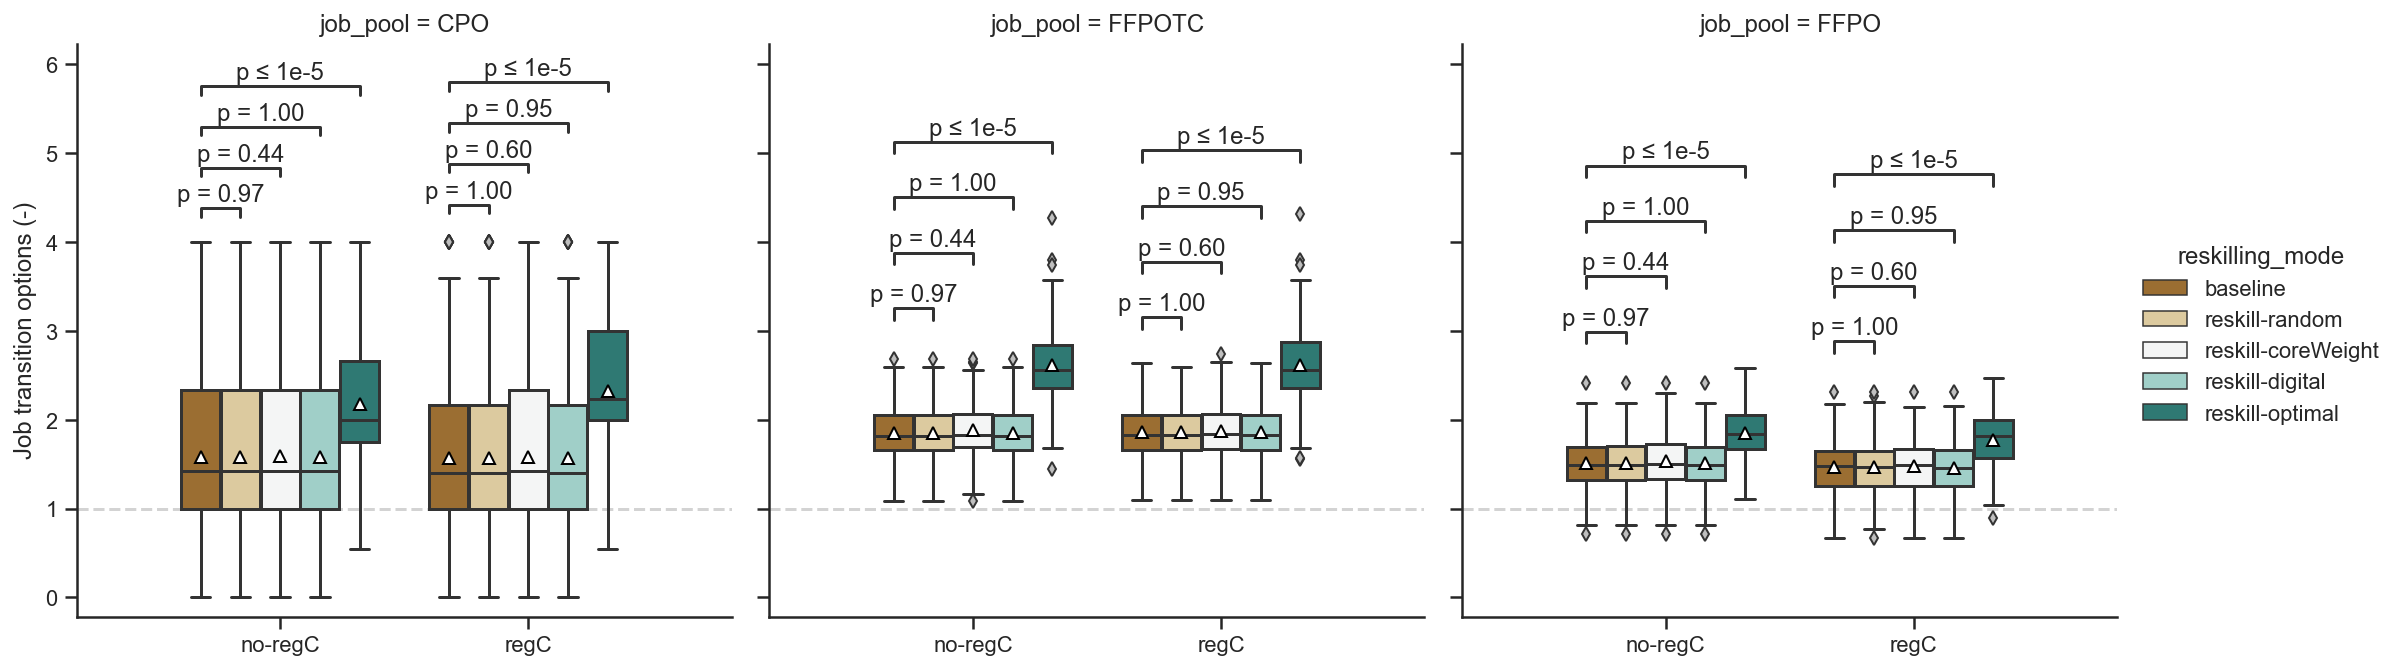

In [267]:
x = "regional_constraint"
y = "n_viable_transitions" #"earnings_delta_closest_switch_sum_mio"
hue = "reskilling_mode"
col = "job_pool"
order = ["no-regC", "regC"]
sharey = True
kind="box"

g = sns.catplot(
    data=df_final,
    col=col,
    x=x,
    y=y,
    hue=hue,
    order=order,
    kind=kind,
    sharey=sharey,
    #ci="sd",
    flierprops=dict(markerfacecolor='0.75', markersize=5, linestyle='none'),
    showmeans=True,
    meanprops=dict(markerfacecolor="white", markeredgecolor="black"),
    height=5,
    aspect=1,
    palette="BrBG"
)

# annotate stats
axes = g.axes.flatten()
for ax in axes:
    ax.axhline(1, linestyle="--", color="lightgrey", zorder=0)
    ax.set_xlabel(None)

    # test statistic
    annotator = Annotator(
        ax, pairs, data=df_final, x=x, y=y, order=order, hue=hue
    )
    annotator.configure(
        test="Kruskal",
        comparisons_correction="Benjamini-Hochberg",
        text_format="simple",
        loc="inside",
        show_test_name=False,
    )
    annotator.apply_and_annotate()

axes[0].set_ylabel("Job transition options (-)")

plt.savefig(
    os.path.join(
        useful_paths.figure_dir,
        "reskilling_final_thresh-{}".format(threshold),
        "model_run_comparison_transitions_{kind}.png".format(kind=kind),
    ),
    bbox_inches="tight",
    dpi=300,
)

no-regC_baseline vs. no-regC_reskill-random: Kruskal-Wallis independent samples (pairwise between groups) with Benjamini-Hochberg correction, P_val:9.716e-01 Stat=1.269e-03
regC_baseline vs. regC_reskill-random: Kruskal-Wallis independent samples (pairwise between groups) with Benjamini-Hochberg correction, P_val:9.976e-01 Stat=8.698e-06
no-regC_baseline vs. no-regC_reskill-coreWeight: Kruskal-Wallis independent samples (pairwise between groups) with Benjamini-Hochberg correction, P_val:4.439e-01 Stat=5.861e-01
regC_baseline vs. regC_reskill-coreWeight: Kruskal-Wallis independent samples (pairwise between groups) with Benjamini-Hochberg correction, P_val:6.006e-01 Stat=2.741e-01
regC_baseline vs. regC_reskill-digital: Kruskal-Wallis independent samples (pairwise between groups) with Benjamini-Hochberg correction, P_val:9.543e-01 Stat=3.281e-03
no-regC_baseline vs. no-regC_reskill-digital: Kruskal-Wallis independent samples (pairwise between groups) with Benjamini-Hochberg correction, P

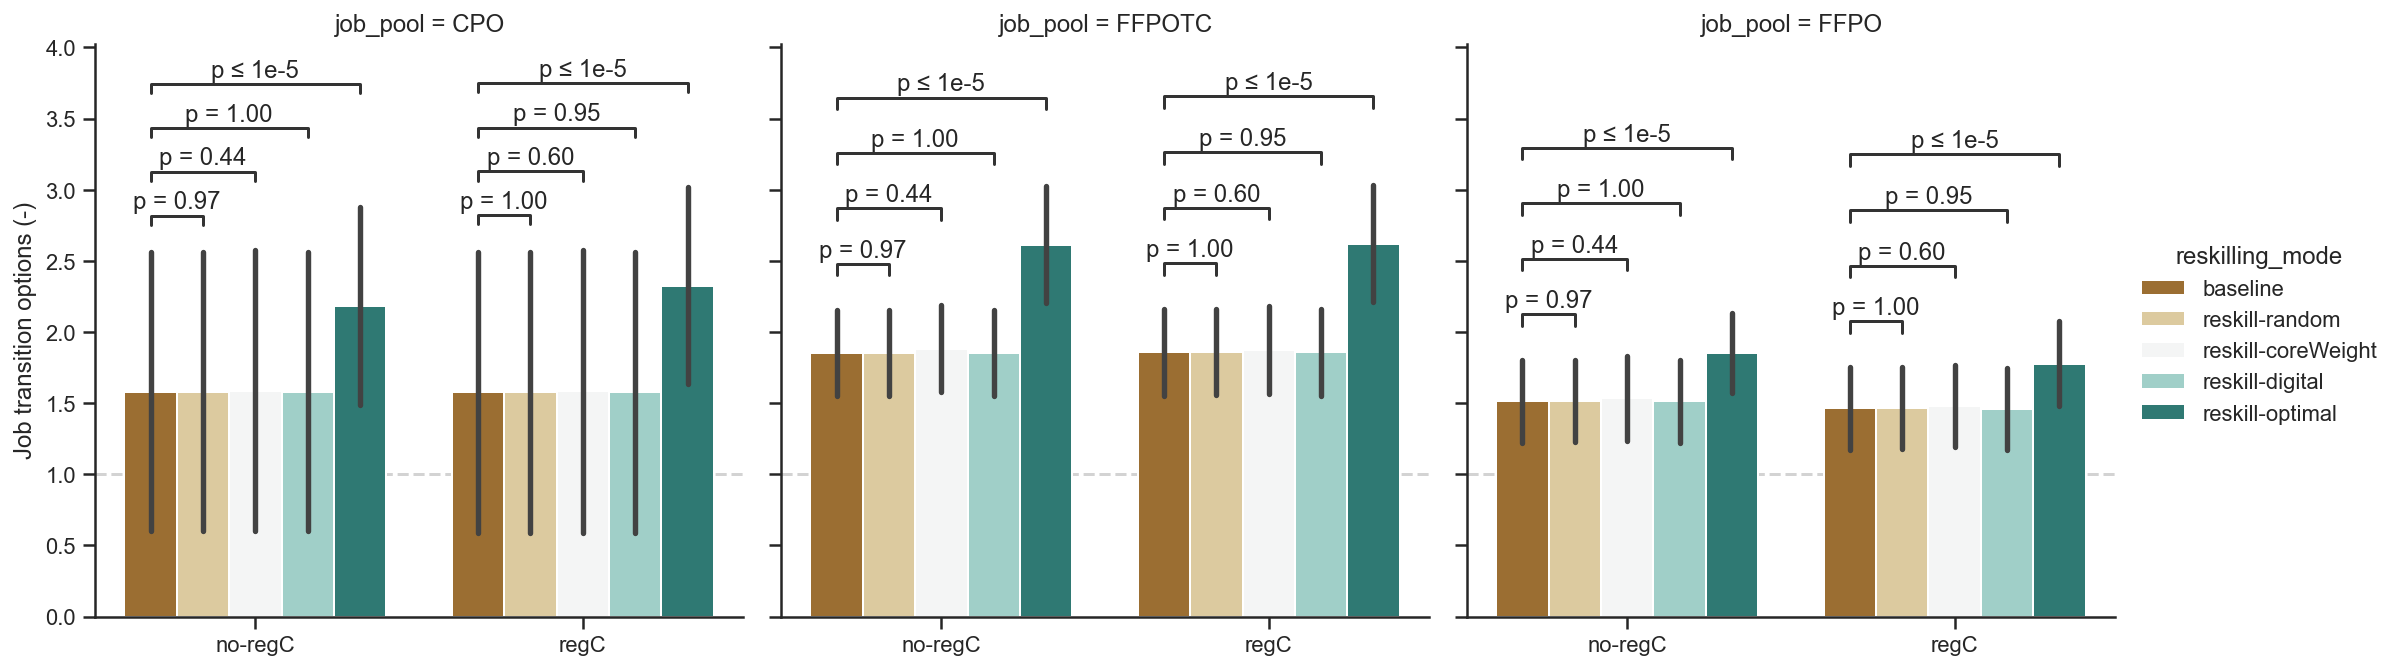

In [268]:
x = "regional_constraint"
y = "n_viable_transitions" #"earnings_delta_closest_switch_sum_mio"
hue = "reskilling_mode"
col = "job_pool"
order = ["no-regC", "regC"]
sharey = True
kind="bar"

g = sns.catplot(
    data=df_final,
    col=col,
    x=x,
    y=y,
    hue=hue,
    order=order,
    kind=kind,
    sharey=sharey,
    estimator=np.mean,
    ci="sd",
    height=5,
    aspect=1,
    palette="BrBG"
)

# annotate stats
axes = g.axes.flatten()
for ax in axes:
    ax.axhline(1, linestyle="--", color="lightgrey", zorder=0)
    ax.set_xlabel(None)

    # test statistic
    annotator = Annotator(
        ax, pairs, data=df_final, x=x, y=y, order=order, hue=hue
    )
    annotator.configure(
        test="Kruskal",
        comparisons_correction="Benjamini-Hochberg",
        text_format="simple",
        loc="inside",
        show_test_name=False,
    )
    annotator.apply_and_annotate()

axes[0].set_ylabel("Job transition options (-)")

plt.savefig(
    os.path.join(
        useful_paths.figure_dir,
        "reskilling_final_thresh-{}".format(threshold),
        "model_run_comparison_transitions_{kind}.png".format(kind=kind),
    ),
    bbox_inches="tight",
    dpi=300,
)

Hue = regional constraint

reskill-random_regC vs. reskill-random_no-regC: Kruskal-Wallis independent samples (pairwise between groups) with Benjamini-Hochberg correction, P_val:4.880e-01 Stat=4.810e-01
baseline_regC vs. baseline_no-regC: Kruskal-Wallis independent samples (pairwise between groups) with Benjamini-Hochberg correction, P_val:5.128e-01 Stat=4.283e-01
reskill-coreWeight_regC vs. reskill-coreWeight_no-regC: Kruskal-Wallis independent samples (pairwise between groups) with Benjamini-Hochberg correction, P_val:3.792e-01 Stat=7.732e-01
reskill-digital_regC vs. reskill-digital_no-regC: Kruskal-Wallis independent samples (pairwise between groups) with Benjamini-Hochberg correction, P_val:4.742e-01 Stat=5.122e-01
reskill-optimal_regC vs. reskill-optimal_no-regC: Kruskal-Wallis independent samples (pairwise between groups) with Benjamini-Hochberg correction, P_val:7.098e-01 Stat=1.384e-01
reskill-random_regC vs. reskill-random_no-regC: Kruskal-Wallis independent samples (pairwise between groups) with Benjam

Text(27.289475000000003, 0.5, 'Job transition options (-)')

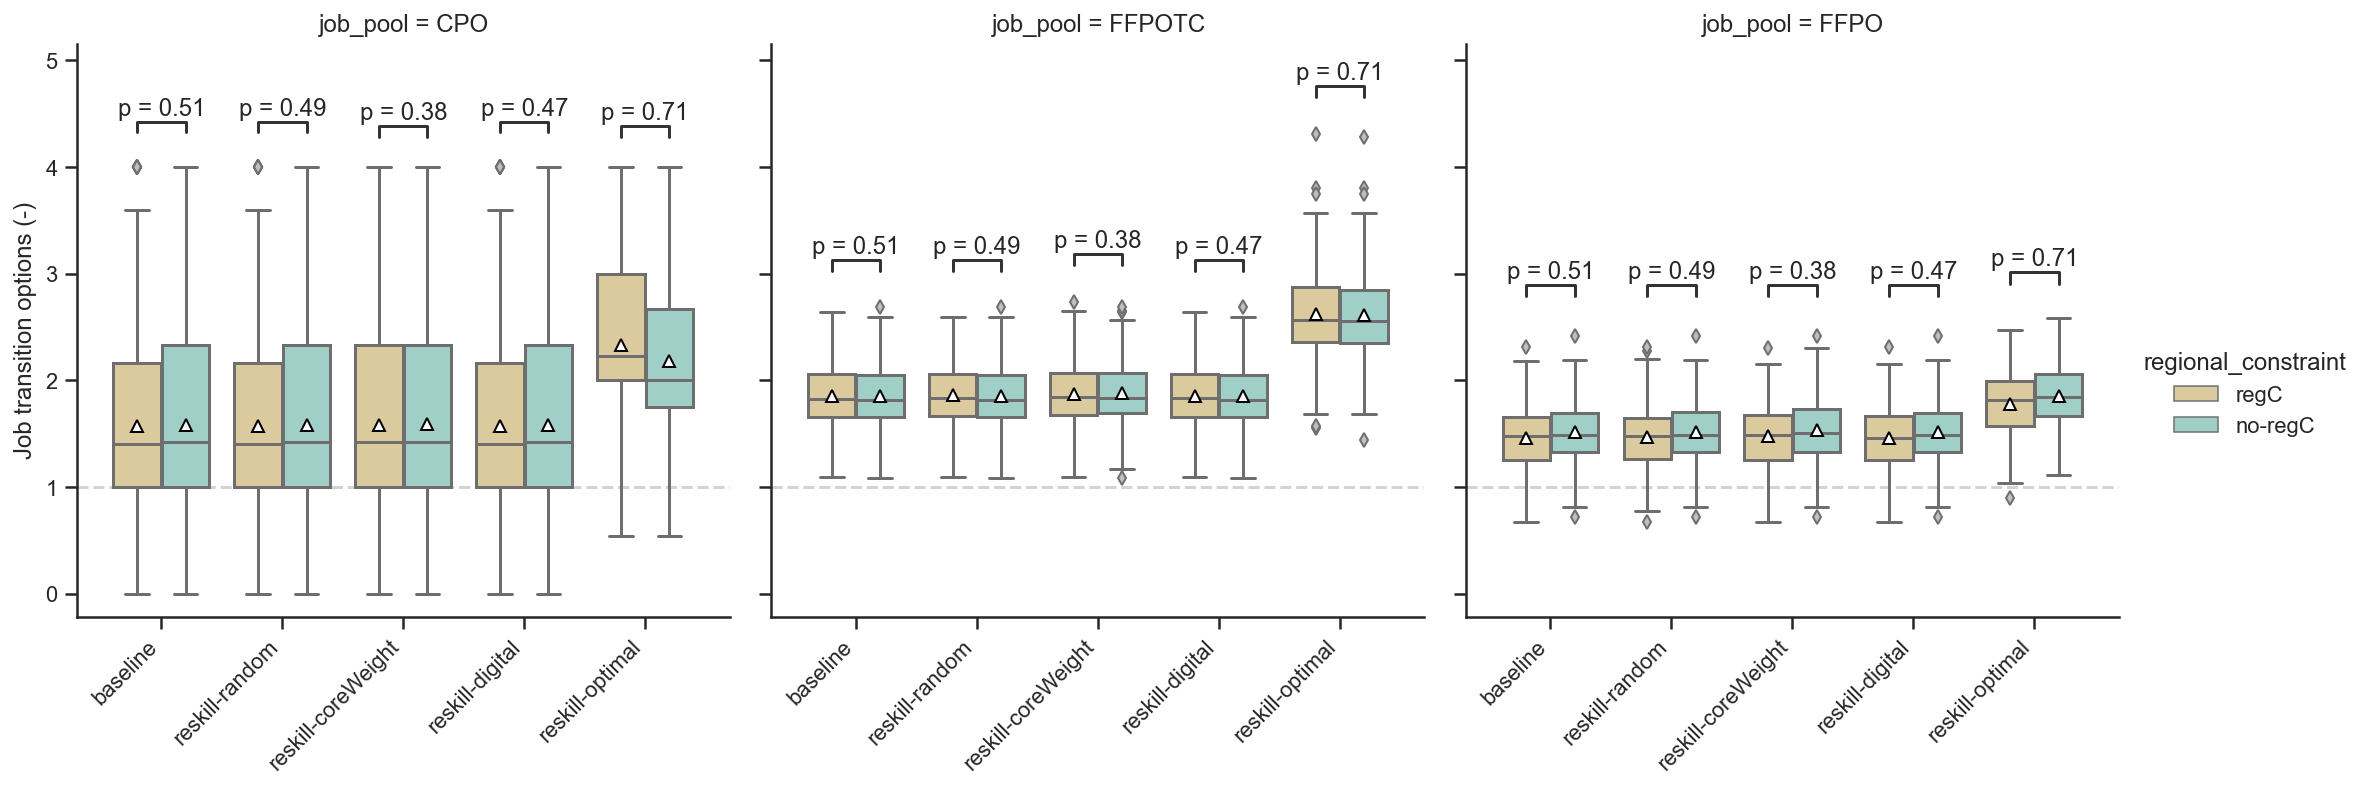

In [269]:
x = "reskilling_mode"
y = "n_viable_transitions" #"earnings_delta_closest_switch_sum_mio"
hue = "regional_constraint"
col = "job_pool"
#order = ["no-regC", "regC"]
sharey = True

g = sns.catplot(
    data=df_final,
    col=col,
    x=x,
    y=y,
    hue=hue,
    #order=order,
    kind="box",
    sharey=sharey,
    flierprops=dict(markerfacecolor='0.75', markersize=5, linestyle='none'),
    showmeans=True,
    meanprops=dict(markerfacecolor="white", markeredgecolor="black"),
    palette="BrBG"
)

axes = g.axes.flatten()
for ax in axes:
    ax.axhline(1, linestyle="--", color="lightgrey", zorder=0)
    ax.set_xticks(ax.get_xticks(), ax.get_xticklabels(), rotation=45, ha='right')
    ax.set_xlabel(None)

    # test statistic
    annotator = Annotator(
        ax, pairs_regional_hue, data=df_final, x=x, y=y, hue=hue
    )
    annotator.configure(
        test="Kruskal",
        comparisons_correction="Benjamini-Hochberg",
        text_format="simple",
        loc="inside",
        show_test_name=False,
    )
    annotator.apply_and_annotate()

axes[0].set_ylabel("Job transition options (-)")

##### Income changes

John Tukey, who was a driving force in the development of exploratory data analysis, defined outliers as points more than 1.5 x IQR. Recall that IQR is the inter-quartile range, which captures 50% of the data points in a data set.

[https://neuraldatascience.io/5-eda/data_cleaning.html]()


Hue = reskilling mode

no-regC_baseline vs. no-regC_reskill-random: Kruskal-Wallis independent samples (pairwise between groups) with Benjamini-Hochberg correction, P_val:9.939e-01 Stat=5.809e-05
regC_baseline vs. regC_reskill-random: Kruskal-Wallis independent samples (pairwise between groups) with Benjamini-Hochberg correction, P_val:9.999e-01 Stat=1.294e-08
no-regC_baseline vs. no-regC_reskill-coreWeight: Kruskal-Wallis independent samples (pairwise between groups) with Benjamini-Hochberg correction, P_val:9.166e-01 Stat=1.098e-02
regC_baseline vs. regC_reskill-coreWeight: Kruskal-Wallis independent samples (pairwise between groups) with Benjamini-Hochberg correction, P_val:9.506e-01 Stat=3.844e-03
regC_baseline vs. regC_reskill-digital: Kruskal-Wallis independent samples (pairwise between groups) with Benjamini-Hochberg correction, P_val:9.957e-01 Stat=2.859e-05
no-regC_baseline vs. no-regC_reskill-digital: Kruskal-Wallis independent samples (pairwise between groups) with Benjamini-Hochberg correction, P

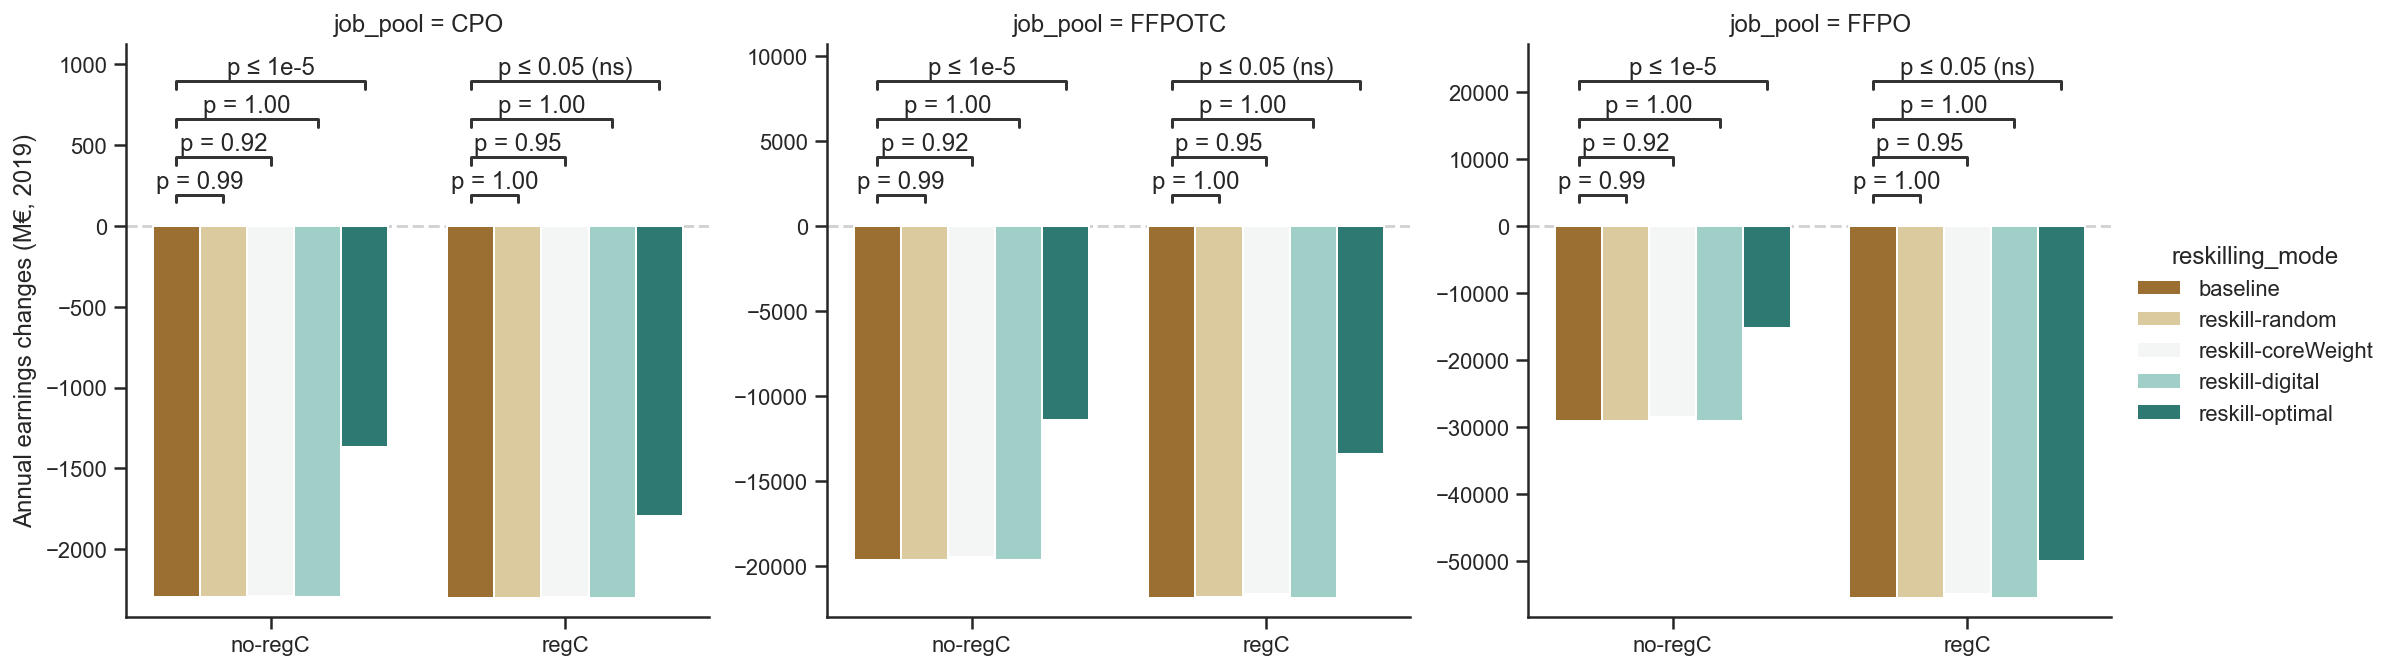

In [270]:
x = "regional_constraint"
y = "earnings_delta_closest_switch_sum_mio" #"earnings_delta_closest_switch_sum_mio"
hue = "reskilling_mode"
col = "job_pool"
order = ["no-regC", "regC"]
sharey = False
kind = "bar"

g = sns.catplot(
    data=df_final,
    col=col,
    x=x,
    y=y,
    order=order,
    hue=hue,
    kind=kind,
    sharey=sharey,
    estimator=np.sum,
    height=5,
    aspect=1,
    ci=None,
    palette="BrBG"
    #flierprops=dict(markerfacecolor='0.75', markersize=5, linestyle='none'),
    #showmeans=True,
    #meanprops=dict(markerfacecolor="white", markeredgecolor="black")
)

# annotate stats
axes = g.axes.flatten()
for ax in axes:
    ax.axhline(0, linestyle="--", color="lightgrey", zorder=0)
    ax.set_xlabel(None)
    # test statistic
    annotator = Annotator(
        ax, pairs, data=df_final, x=x, y=y, order=order, hue=hue
    )
    annotator.configure(
        test="Kruskal",
        comparisons_correction="Benjamini-Hochberg",
        text_format="simple",
        loc="inside",
        show_test_name=False,
    )
    annotator.apply_and_annotate()

axes[0].set_ylabel("Annual earnings changes (M€, 2019)")

# save
#plt.tight_layout()
plt.savefig(
    os.path.join(
        useful_paths.figure_dir,
        "reskilling_final_thresh-{}".format(threshold),
        "model_run_comparison_earnings_delta_{kind}_sum.png".format(kind=kind),
    ),
    bbox_inches="tight",
    dpi=300,
)

no-regC_baseline vs. no-regC_reskill-random: Kruskal-Wallis independent samples (pairwise between groups) with Benjamini-Hochberg correction, P_val:9.939e-01 Stat=5.809e-05
regC_baseline vs. regC_reskill-random: Kruskal-Wallis independent samples (pairwise between groups) with Benjamini-Hochberg correction, P_val:9.999e-01 Stat=1.294e-08
no-regC_baseline vs. no-regC_reskill-coreWeight: Kruskal-Wallis independent samples (pairwise between groups) with Benjamini-Hochberg correction, P_val:9.166e-01 Stat=1.098e-02
regC_baseline vs. regC_reskill-coreWeight: Kruskal-Wallis independent samples (pairwise between groups) with Benjamini-Hochberg correction, P_val:9.506e-01 Stat=3.844e-03
regC_baseline vs. regC_reskill-digital: Kruskal-Wallis independent samples (pairwise between groups) with Benjamini-Hochberg correction, P_val:9.957e-01 Stat=2.859e-05
no-regC_baseline vs. no-regC_reskill-digital: Kruskal-Wallis independent samples (pairwise between groups) with Benjamini-Hochberg correction, P

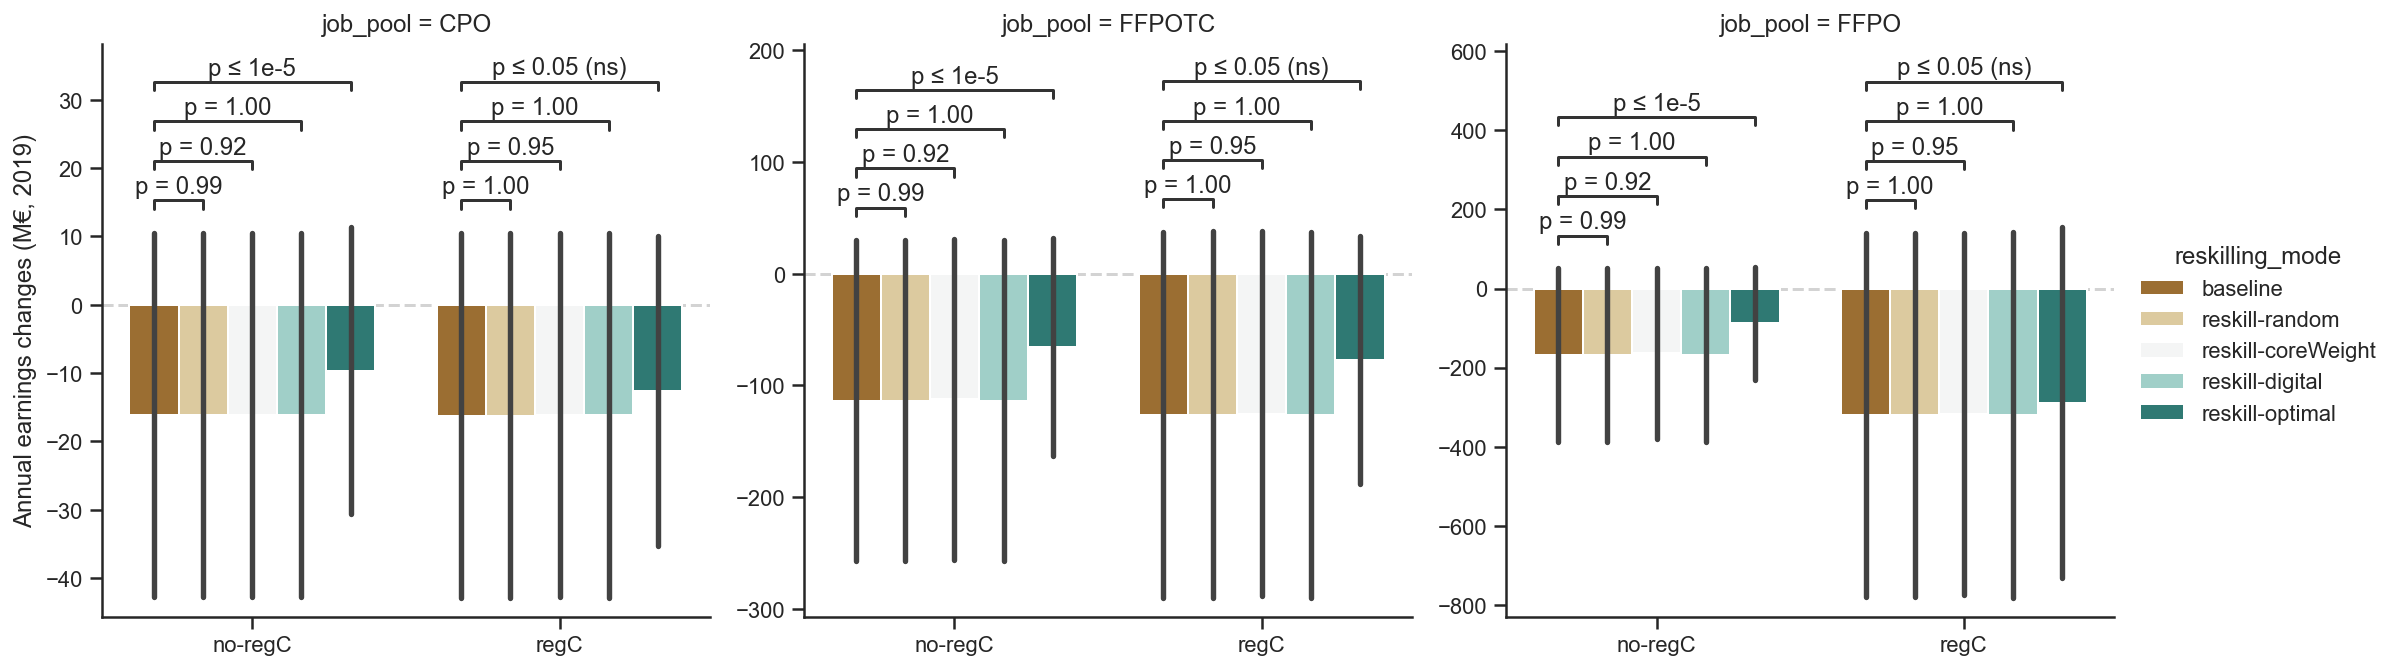

In [271]:
x = "regional_constraint"
y = "earnings_delta_closest_switch_sum_mio" #"earnings_delta_closest_switch_sum_mio"
hue = "reskilling_mode"
col = "job_pool"
order = ["no-regC", "regC"]
sharey = False
kind = "bar"

g = sns.catplot(
    data=df_final,
    col=col,
    x=x,
    y=y,
    order=order,
    hue=hue,
    kind=kind,
    sharey=sharey,
    estimator=np.mean,
    height=5,
    aspect=1,
    ci="sd",
    palette="BrBG"
    #flierprops=dict(markerfacecolor='0.75', markersize=5, linestyle='none'),
    #showmeans=True,
    #meanprops=dict(markerfacecolor="white", markeredgecolor="black")
)

# annotate stats
axes = g.axes.flatten()
for ax in axes:
    ax.axhline(0, linestyle="--", color="lightgrey", zorder=0)
    ax.set_xlabel(None)
    # test statistic
    annotator = Annotator(
        ax, pairs, data=df_final, x=x, y=y, order=order, hue=hue
    )
    annotator.configure(
        test="Kruskal",
        comparisons_correction="Benjamini-Hochberg",
        text_format="simple",
        loc="inside",
        show_test_name=False,
    )
    annotator.apply_and_annotate()

axes[0].set_ylabel("Annual earnings changes (M€, 2019)")

# save
#plt.tight_layout()
plt.savefig(
    os.path.join(
        useful_paths.figure_dir,
        "reskilling_final_thresh-{}".format(threshold),
        "model_run_comparison_earnings_delta_{kind}_mean.png".format(kind=kind),
    ),
    bbox_inches="tight",
    dpi=300,
)

no-regC_baseline vs. no-regC_reskill-random: Kruskal-Wallis independent samples (pairwise between groups) with Benjamini-Hochberg correction, P_val:9.939e-01 Stat=5.809e-05
regC_baseline vs. regC_reskill-random: Kruskal-Wallis independent samples (pairwise between groups) with Benjamini-Hochberg correction, P_val:9.999e-01 Stat=1.294e-08
no-regC_baseline vs. no-regC_reskill-coreWeight: Kruskal-Wallis independent samples (pairwise between groups) with Benjamini-Hochberg correction, P_val:9.166e-01 Stat=1.098e-02
regC_baseline vs. regC_reskill-coreWeight: Kruskal-Wallis independent samples (pairwise between groups) with Benjamini-Hochberg correction, P_val:9.506e-01 Stat=3.844e-03
regC_baseline vs. regC_reskill-digital: Kruskal-Wallis independent samples (pairwise between groups) with Benjamini-Hochberg correction, P_val:9.957e-01 Stat=2.859e-05
no-regC_baseline vs. no-regC_reskill-digital: Kruskal-Wallis independent samples (pairwise between groups) with Benjamini-Hochberg correction, P

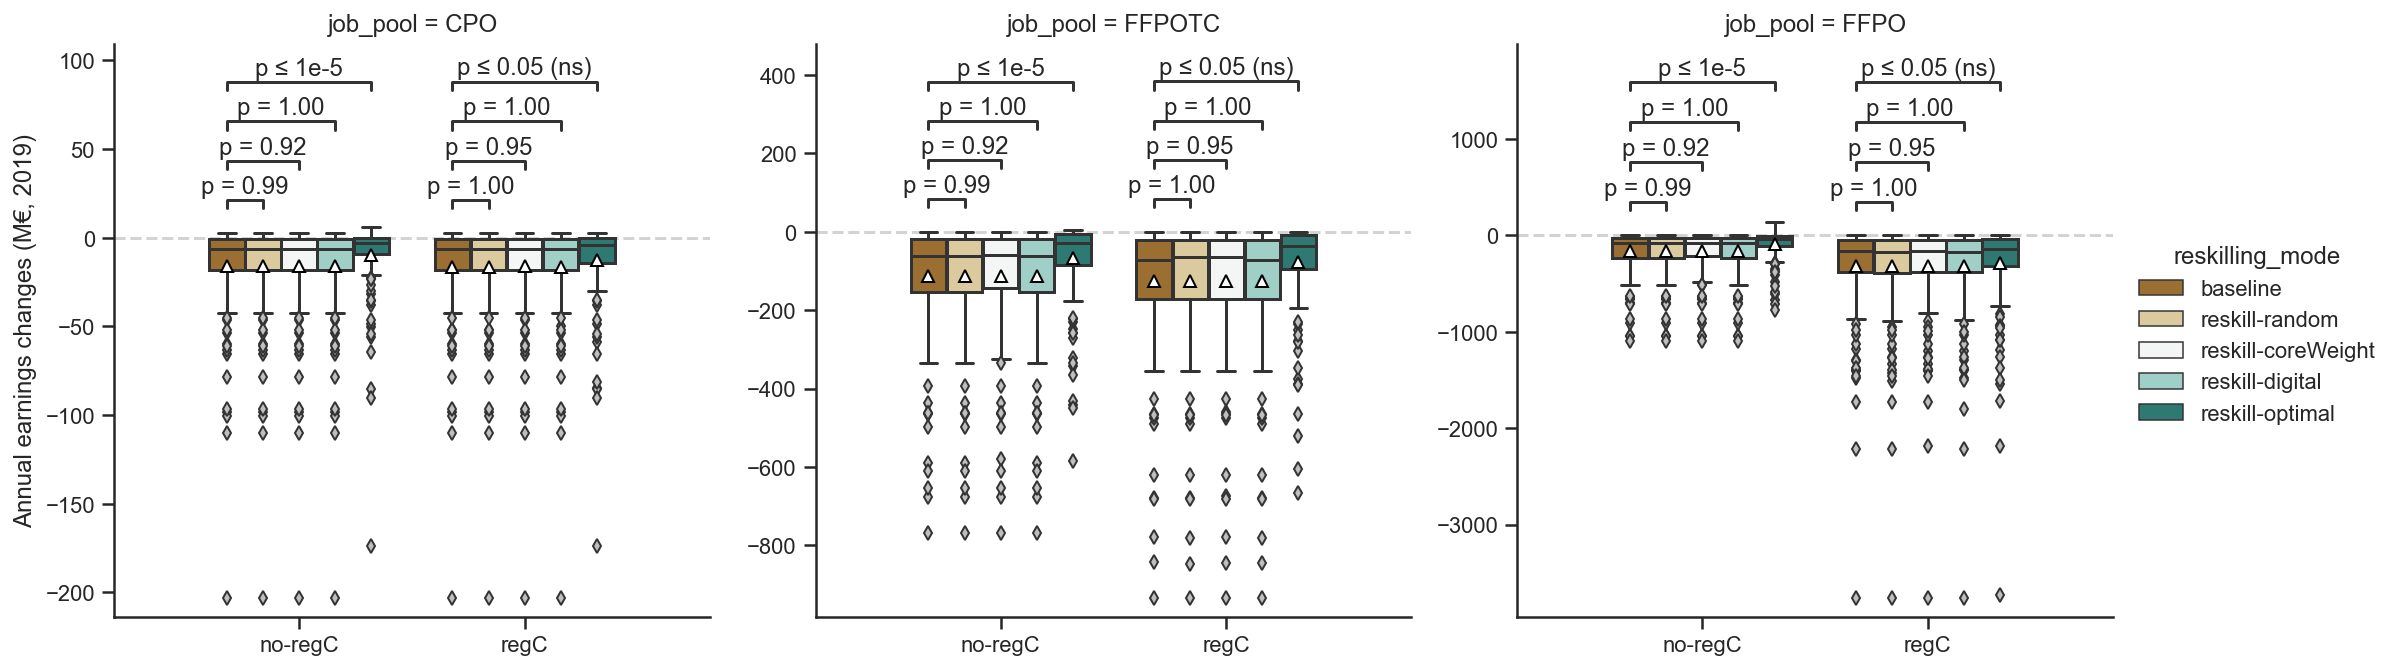

In [272]:
x = "regional_constraint"
y = "earnings_delta_closest_switch_sum_mio" #"earnings_delta_closest_switch_sum_mio"
hue = "reskilling_mode"
col = "job_pool"
order = ["no-regC", "regC"]
sharey = False
kind = "box"

g = sns.catplot(
    data=df_final,
    col=col,
    x=x,
    y=y,
    order=order,
    hue=hue,
    kind=kind,
    sharey=sharey,
    height=5,
    aspect=1,
    flierprops=dict(markerfacecolor='0.75', markersize=5, linestyle='none'),
    showmeans=True,
    meanprops=dict(markerfacecolor="white", markeredgecolor="black"),
    palette="BrBG"
)

# annotate stats
axes = g.axes.flatten()
for ax in axes:
    ax.axhline(0, linestyle="--", color="lightgrey", zorder=0)
    ax.set_xlabel(None)
    # test statistic
    annotator = Annotator(
        ax, pairs, data=df_final, x=x, y=y, order=order, hue=hue
    )
    annotator.configure(
        test="Kruskal",
        comparisons_correction="Benjamini-Hochberg",
        text_format="simple",
        loc="inside",
        show_test_name=False,
    )
    annotator.apply_and_annotate()

axes[0].set_ylabel("Annual earnings changes (M€, 2019)")

# save
#plt.tight_layout()
plt.savefig(
    os.path.join(
        useful_paths.figure_dir,
        "reskilling_final_thresh-{}".format(threshold),
        "model_run_comparison_earnings_delta_{kind}.png".format(kind=kind),
    ),
    bbox_inches="tight",
    dpi=300,
)

Hue = regional constraint

reskill-random_regC vs. reskill-random_no-regC: Kruskal-Wallis independent samples (pairwise between groups) with Benjamini-Hochberg correction, P_val:4.529e-02 Stat=4.008e+00
baseline_regC vs. baseline_no-regC: Kruskal-Wallis independent samples (pairwise between groups) with Benjamini-Hochberg correction, P_val:4.639e-02 Stat=3.967e+00
reskill-coreWeight_regC vs. reskill-coreWeight_no-regC: Kruskal-Wallis independent samples (pairwise between groups) with Benjamini-Hochberg correction, P_val:4.411e-02 Stat=4.052e+00
reskill-digital_regC vs. reskill-digital_no-regC: Kruskal-Wallis independent samples (pairwise between groups) with Benjamini-Hochberg correction, P_val:4.512e-02 Stat=4.014e+00
reskill-optimal_regC vs. reskill-optimal_no-regC: Kruskal-Wallis independent samples (pairwise between groups) with Benjamini-Hochberg correction, P_val:3.215e-06 Stat=2.168e+01
reskill-random_regC vs. reskill-random_no-regC: Kruskal-Wallis independent samples (pairwise between groups) with Benjam

Text(29.234657291666664, 0.5, 'Annual earnings changes (M€, 2019)')

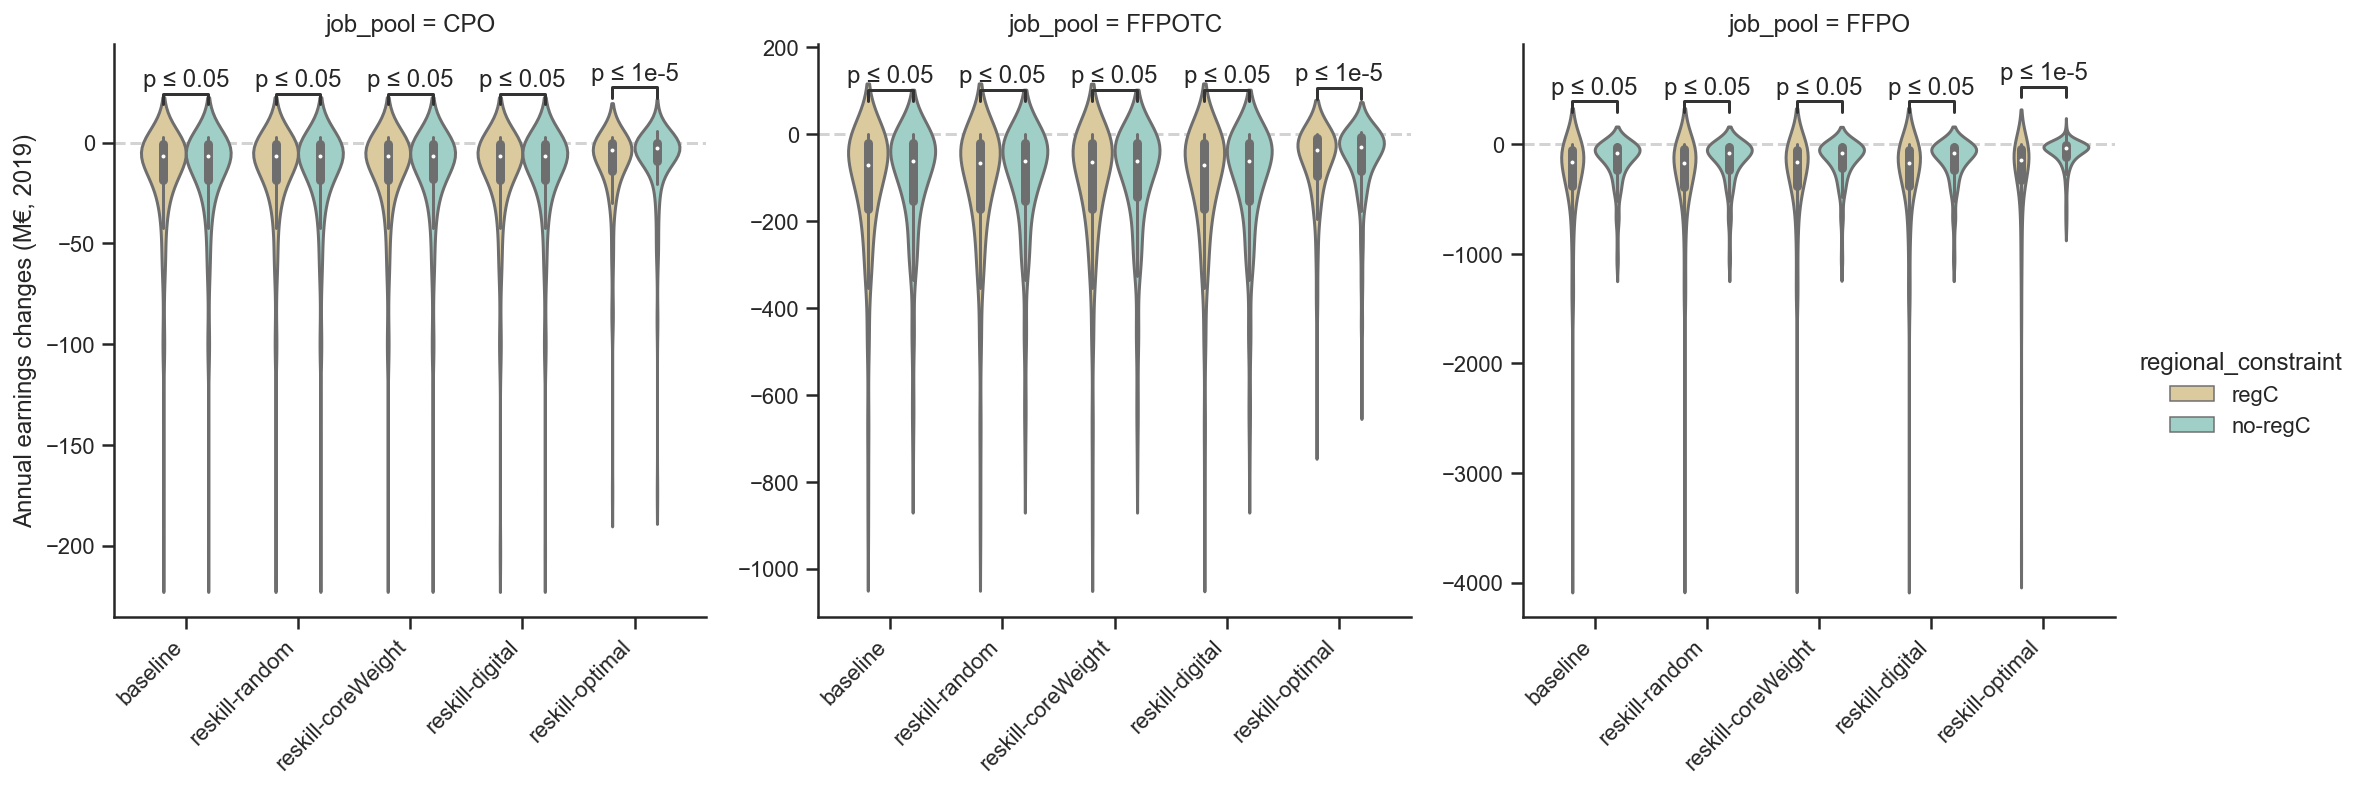

In [273]:
x = "reskilling_mode"
y = "earnings_delta_closest_switch_sum_mio" #"earnings_delta_closest_switch_sum_mio"
hue = "regional_constraint"
col = "job_pool"
#order = ["no-regC", "regC"]
sharey = False

g = sns.catplot(
    data=df_final,
    col=col,
    x=x,
    y=y,
    hue=hue,
    #order=order,
    kind="violin",
    sharey=sharey,
    flierprops=dict(markerfacecolor='0.75', markersize=5, linestyle='none'),
    showmeans=True,
    meanprops=dict(markerfacecolor="white", markeredgecolor="black"),
    palette="BrBG"
)

axes = g.axes.flatten()
for ax in axes:
    ax.set_xticks(ax.get_xticks(), ax.get_xticklabels(), rotation=45, ha='right')
    ax.set_xlabel(None)
    ax.axhline(0, linestyle="--", color="lightgrey", zorder=0)

    # test statistic
    annotator = Annotator(
        ax, pairs_regional_hue, data=df_final, x=x, y=y, hue=hue
    )
    annotator.configure(
        test="Kruskal",
        comparisons_correction="Benjamini-Hochberg",
        text_format="simple",
        loc="inside",
        show_test_name=False,
    )
    annotator.apply_and_annotate()

axes[0].set_ylabel("Annual earnings changes (M€, 2019)")